In [1]:
!pip install pandas, scikit-learn, lightgbm, xgboost, catboost, optuna, shap, matplotlib, seabornn,


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: 'pandas,': Expected end or semicolon (after name and no valid version specifier)
    pandas,
          ^


In [2]:
!pip install optuna


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import matplotlib.pyplot as plt
import platform

# 운영체제에 맞춰 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [4]:
import pandas as pd

# 1. train 데이터 로드
train = pd.read_csv('train.csv')

# 2. 데이터 명세 엑셀 파일 로드 (read_excel 사용)
# 파일명이 정확히 '데이터 명세.xlsx'라고 가정합니다
spec = pd.read_excel('데이터 명세.xlsx')

# 3. 데이터 확인
print("--- Train 데이터 미리보기 ---")
print(train.head())

print("\n--- 데이터 명세 미리보기 ---")
print(spec.head())

--- Train 데이터 미리보기 ---
             ID 시술 시기 코드 시술 당시 나이  임신 시도 또는 마지막 임신 경과 연수 시술 유형 특정 시술 유형  \
0  TRAIN_000000   TRZKPL  만18-34세                    NaN   IVF     ICSI   
1  TRAIN_000001   TRYBLT  만45-50세                    NaN   IVF     ICSI   
2  TRAIN_000002   TRVNRY  만18-34세                    NaN   IVF      IVF   
3  TRAIN_000003   TRJXFG  만35-37세                    NaN   IVF     ICSI   
4  TRAIN_000004   TRVNRY  만18-34세                    NaN   IVF     ICSI   

   배란 자극 여부    배란 유도 유형  단일 배아 이식 여부  착상 전 유전 검사 사용 여부  ...  기증 배아 사용 여부  \
0         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
1         0      알 수 없음          0.0               NaN  ...          0.0   
2         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
3         1  기록되지 않은 시행          0.0               NaN  ...          0.0   
4         1  기록되지 않은 시행          0.0               NaN  ...          0.0   

   대리모 여부  PGD 시술 여부  PGS 시술 여부  난자 채취 경과일  난자 해동 경과일  난자 혼합 경과일  배아 

In [5]:
import re
from sklearn.preprocessing import LabelEncoder
import pandas as pd

meta_data = {}
# 타겟 컬럼 이름을 설정하세요 (데이터셋에 맞춰 수정 가능)
TARGET_COL = '임신 성공 여부' 

def preprocess_final(df, is_train=True, train_columns=None):
    df = df.copy()
    
    # [타겟 보호] 전처리 시작 전 타겟을 잠시 분리
    target_data = None
    if TARGET_COL in df.columns:
        target_data = df[TARGET_COL]
        df = df.drop(columns=[TARGET_COL])
    # 1. 시도 여부 컬럼 결측치 '0'으로 채우기 (시도 안 했음을 명시)
    flag_cols = ['PGS 시술 여부', 'PGD 시술 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부']

    for col in flag_cols:
        if col in df.columns:
            # 결측치를 0으로 채우고 정수형으로 변환
            df[col] = df[col].fillna(0).astype(int)

    # 2. 도메인 지식 기반 보정 (PGD/PGS 관계성)
    # 명세서에 따라 착상 전 유전 검사 사용 여부가 1이면 PGS도 1로 보정
    df.loc[df['착상 전 유전 검사 사용 여부'] == 1, 'PGS 시술 여부'] = 1
    df.loc[df['착상 전 유전 진단 사용 여부'] == 1, 'PGD 시술 여부'] = 1
    # --- 기존 전처리 로직 시작 ---
    # 1. 나이 구획화
    def bin_age(age_str):
        age_map = {'만18-34세': 1, '만35-37세': 2, '만38-39세': 3, 
                   '만40-42세': 3, '만43-44세': 4, '만45-50세': 4, '알 수 없음': 2}
        return age_map.get(str(age_str), 2)

    age_cols = ['시술 당시 나이', '난자 기증자 나이', '정자 기증자 나이']
    for col in age_cols:
        if col in df.columns:
            df[f'{col}_구획'] = df[col].apply(bin_age)
            df = df.drop(columns=[col])

    # 2. 범주형 변수 처리
    categorical_cols = ['시술 유형', '시술 시기 코드', '난자 출처', '정자 출처']
    for col in categorical_cols:
        if col in df.columns:
            df[col] = df[col].fillna('알 수 없음')
            if is_train:
                le = LabelEncoder()
                df[col] = le.fit_transform(df[col].astype(str))
                meta_data[col] = le
            else:
                le = meta_data.get(col)
                df[col] = df[col].apply(lambda x: le.transform([x])[0] if (le and x in le.classes_) else -1)

    # 3. 숫자 컬럼 정제
    count_cols = ['총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', 
                  '총 임신 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', '총 출산 횟수', 'IVF 출산 횟수', 'DI 출산 횟수']
    for col in count_cols:
        if col in df.columns:
            df[col] = df[col].astype(str).apply(lambda x: re.sub(r'[^0-9]', '', x))
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)

    # 4. 원-핫 인코딩
    if '배아 생성 주요 이유' in df.columns:
        df = pd.get_dummies(df, columns=['배아 생성 주요 이유'], prefix='이유')

    # [핵심] Train 구조 반영하기
    if not is_train and train_columns is not None:
        for col in train_columns:
            if col not in df.columns:
                df[col] = 0
        df = df[train_columns]
    # --- 기존 전처리 로직 끝 ---

    # [타겟 복구] 전처리 완료 후 타겟 재결합
    if target_data is not None:
        df[TARGET_COL] = target_data
        
    return df

# 1. 원본 데이터 로드
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

# 2. Train 전처리
train_df = preprocess_final(train, is_train=True)

# 3. [핵심 수정] 타겟 컬럼을 제외한 피처 컬럼 리스트만 추출
# train_df에서 타겟 컬럼만 뺀 순수 피처 컬럼들로만 test_df의 구조를 맞춥니다.
feature_columns = [col for col in train_df.columns if col != TARGET_COL]

# 4. Test 전처리 (타겟 컬럼이 제거된 피처 리스트만 전달)
test_df = preprocess_final(test, is_train=False, train_columns=feature_columns)

# 이제 test_df에는 타겟 컬럼이 존재하지 않으며, 피처 구조는 train_df와 완벽히 일치합니다.
print(f"Train 컬럼 수 (타겟 포함): {len(train_df.columns)}")
print(f"Test 컬럼 수 (타겟 제외): {len(test_df.columns)}")

Train 컬럼 수 (타겟 포함): 81
Test 컬럼 수 (타겟 제외): 80


In [6]:
import re
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# 인코더 저장소
meta_data = {}
TARGET_COL = '임신 성공 여부' # 실제 데이터의 타겟 컬럼명으로 설정

def process_specific_cols(df, is_train=True, train_columns=None):
    df = df.copy()

    # [타겟 보호] 전처리 시작 전 타겟을 잠시 분리
    target_data = None
    if TARGET_COL in df.columns:
        target_data = df[TARGET_COL]
        df = df.drop(columns=[TARGET_COL])

    # 1. 특정 시술 유형 (LabelEncoder 관리)
    if '특정 시술 유형' in df.columns:
        df['특정 시술 유형'] = df['특정 시술 유형'].apply(lambda x: str(x).split('/')[0].strip())
        df['특정 시술 유형'] = df['특정 시술 유형'].replace('Unknown', '알 수 없음')
        
        if is_train:
            le = LabelEncoder()
            df['특정 시술 유형'] = le.fit_transform(df['특정 시술 유형'].astype(str))
            meta_data['le_proc_type'] = le 
        else:
            le = meta_data.get('le_proc_type')
            df['특정 시술 유형'] = df['특정 시술 유형'].apply(lambda x: le.transform([x])[0] if (le and x in le.classes_) else -1)

    # 2. 배란 유도 유형
    if '배란 유도 유형' in df.columns:
        df['배란 유도 유형'] = df['배란 유도 유형'].replace('알 수 없음', '기록되지 않은 시행')
        ovulation_map = {'기록되지 않은 시행': 0, '세트로타이드(억제제)': 1, '생식선 자극호르몬': 2}
        df['배란 유도 유형'] = df['배란 유도 유형'].map(ovulation_map).fillna(0).astype(int)

    # 4. 원-핫 인코딩
    if '배아 생성 주요 이유' in df.columns:
        df = pd.get_dummies(df, columns=['배아 생성 주요 이유'], prefix='이유')

    if 'ID' in df.columns:
        df = df.drop(columns=['ID'])

    # 5. [핵심] Train 데이터 구조 반영 (Test인 경우)
    if not is_train and train_columns is not None:
        for col in train_columns:
            if col not in df.columns:
                df[col] = 0
        df = df[train_columns]    

    # [타겟 복구] 전처리 완료 후 타겟 재결합
    if target_data is not None:
        df[TARGET_COL] = target_data
        
    return df

# 실행
# 먼저 전처리 함수를 통해 데이터 전체를 가공
train_df = process_specific_cols(train_df, is_train=True)
test_df = process_specific_cols(test_df, is_train=False, train_columns=train_df.drop(columns=[TARGET_COL]).columns)
# 이제 test_df에는 타겟 컬럼이 존재하지 않으며, 피처 구조는 train_df와 완벽히 일치합니다.
print(f"Train 컬럼 수 (타겟 포함): {len(train_df.columns)}")
print(f"Test 컬럼 수 (타겟 제외): {len(test_df.columns)}")

Train 컬럼 수 (타겟 포함): 80
Test 컬럼 수 (타겟 제외): 79


In [7]:
#결측전처리 임신기록!
def process_pregnancy_history(df):
    df = df.copy()
    # 1. 플래그 생성: 데이터가 있는가? (1: 있음, 0: 없음)
    df['is_pregnancy_history_known'] = df['임신 시도 또는 마지막 임신 경과 연수'].notnull().astype(int)
    
    # 2. 중앙값 계산
    median_val = df['임신 시도 또는 마지막 임신 경과 연수'].median()
    
    # 3. 결측치를 중앙값으로 채움
    df['임신 시도 또는 마지막 임신 경과 연수'] = df['임신 시도 또는 마지막 임신 경과 연수'].fillna(median_val)
    
    return df
train_df = process_pregnancy_history(train_df)
test_df = process_pregnancy_history(test_df)

In [8]:
# 1. 학습 데이터에서 median_gap 계산 (기존과 동일)
valid_train = train_df[train_df['난자 혼합 경과일'].notnull()]
base_train = train_df[['난자 채취 경과일', '난자 해동 경과일']].max(axis=1)
median_gap = (valid_train['난자 혼합 경과일'] - base_train[valid_train.index]).median()

# 2. 전처리 함수 수정: 결측 처리가 안 된 부분은 -1로 처리하는 로직 추가
def process_mixing_date_final(df, gap):
    df = df.copy()
    base_date = df[['난자 채취 경과일', '난자 해동 경과일']].max(axis=1)
    
    # 1) 우선 프로세스상 계산 가능한 것은 채움
    df['난자 혼합 경과일'] = df['난자 혼합 경과일'].fillna(base_date + gap)
    
    # 2) 여전히 NaN인 것은 '혼합 과정 없음'으로 간주 (-1 처리)
    df['has_mixing_process'] = df['난자 혼합 경과일'].notnull().astype(int)
    df['난자 혼합 경과일'] = df['난자 혼합 경과일'].fillna(-1)
    
    # 3) 음수 방지 및 마무리
    df['난자 혼합 경과일'] = df['난자 혼합 경과일'].clip(lower=-1)
    
    return df

# 3. 적용
train_df = process_mixing_date_final(train_df, median_gap)
test_df = process_mixing_date_final(test_df, median_gap)

In [9]:
#전처리 2차
def preprocess_embryo_cols(df):
    df = df.copy()
    
    embryo_cols = [
        '동결 배아 사용 여부', 
        '신선 배아 사용 여부', 
        '기증 배아 사용 여부',
        '단일 배아 이식 여부',
        '대리모 여부'
    ]
    
    for col in embryo_cols:
        if col in df.columns:
            # 1. 원래 결측치였던 행을 기억하기 위해 플래그 생성
            df[f'{col}_missing'] = df[col].isnull().astype(int)
            
            # 2. 결측치를 0으로 채우기
            df[col] = df[col].fillna(0).astype(int)

    # [사용자님의 통찰 반영]
    # 난자 해동 경과일이 결측인 경우 -> '난자 채취 경과일' 값을 가져옴 (신선 시술임을 가정)
    # 즉, 해동 과정이 없는 경우 채취 시점이 곧 시작 시점과 같다고 판단
    df['난자 해동 경과일'] = df['난자 해동 경과일'].fillna(df['난자 채취 경과일'])
    
    # 배아 해동 경과일 역시 '배아 이식 경과일'과 연결하여 보정
    df['배아 해동 경과일'] = df['배아 해동 경과일'].fillna(df['배아 이식 경과일'])
    
    # 0으로 남은 부분(채취일조차 없는 경우)은 최종 0으로 처리
    df['난자 해동 경과일'] = df['난자 해동 경과일'].fillna(0)
    df['배아 해동 경과일'] = df['배아 해동 경과일'].fillna(0)
    
    minor_missing_cols = [
    '미세주입된 난자 수', '미세주입 배아 이식 수', '미세주입에서 생성된 배아 수',
    '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동 난자 수', 
    '해동된 배아 수', '저장된 신선 난자 수', '혼합된 난자 수', 
    '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수'
    ]

    for col in minor_missing_cols:
        if col in df.columns:
            median_val = df[col].median()
            df[col] = df[col].fillna(median_val)


    return df
# 적용
train_df = preprocess_embryo_cols(train_df)
test_df = preprocess_embryo_cols(test_df)

In [10]:
#데이터엔지니어링!!!
def create_and_refine_features(df):
    df = df.copy()
    
    # [핵심 수정] 연산에 필요한 컬럼들을 강제로 숫자형으로 변환
    # 'coerce'를 쓰면 숫자로 바꿀 수 없는 값은 NaN이 되고, 이후 fillna(0)으로 0이 됩니다.
    cols_to_numeric = ['총 생성 배아 수', '수집된 신선 난자 수', '이식된 배아 수', 
                       '총 출산 횟수', '총 임신 횟수', '배아 이식 경과일', '난자 채취 경과일']
    
    for col in cols_to_numeric:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    
    # 이제 안전하게 연산 수행 가능
    df['embryo_efficiency'] = df['총 생성 배아 수'] / (df['수집된 신선 난자 수'] + 1e-9)
    df['implantation_efficiency'] = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1e-9)
    
    # 여기서 에러가 나던 부분이 해결됩니다.
    df['has_history'] = ((df['총 출산 횟수'] > 0) | (df['총 임신 횟수'] > 0)).astype(int)
    
    cause_cols = [c for c in df.columns if '불임 원인 -' in c]
    df['total_causes_count'] = df[cause_cols].sum(axis=1)
    
    # 배아 이식 경과일이나 난자 채취 경과일 같은 데이터는 
    # 결측치가 많거나 누수 위험이 있다면 신중하게 사용해야 합니다.
    df['time_gap_harvest_to_trans'] = df['배아 이식 경과일'] - df['난자 채취 경과일']
    df['is_elective_SET'] = ((df['이식된 배아 수'] == 1) & (df['시술 당시 나이_구획'] < 35)).astype(int)
    
    # 2. 과적합 방지를 위한 불필요 컬럼 드롭 (제거 리스트)
    # 1) 중요도가 낮거나, 2) ID처럼 정보량이 없는 것, 3) 누수 위험이 큰 것
    drop_cols = [
        'ID', 
        '난자 채취 경과일', # 파생 변수 생성 후 원본 삭제
        '배아 이식 경과일', 
        '총 출산 횟수',     # has_history 생성 후 원본 삭제
        '총 임신 횟수'
    ]
    # 1. 연령 보정
    df['egg_to_age_ratio'] = df['수집된 신선 난자 수'] / (df['시술 당시 나이_구획'] + 1e-9)

    # 3. 경험 지표
    df['history_success_rate'] = df['총 출산 횟수'] / (df['클리닉 내 총 시술 횟수'] + 1e-9)
    
    # 4. 복합 불임 여부
    df['is_complex_cause'] = (df['total_causes_count'] > 1).astype(int)
    # 실제 존재하는 컬럼만 드롭
    existing_drop_cols = [c for c in drop_cols if c in df.columns]
    df = df.drop(columns=existing_drop_cols)
    
    return df

# 적용
train_df = create_and_refine_features(train_df)
test_df = create_and_refine_features(test_df)

In [11]:
import numpy as np
def create_advanced_features(df):
    df = df.copy()
    
    # 1. 효율성 지표 (Efficiency Ratios)
    # 난자 대비 배아 생성 효율
    df['embryo_yield_rate'] = df['총 생성 배아 수'] / (df['수집된 신선 난자 수'] + 1e-9)
    # 배아 대비 이식 효율
    df['transfer_efficiency'] = df['이식된 배아 수'] / (df['총 생성 배아 수'] + 1e-9)

    # 4. 상호작용 피처 (Interaction Features)
    # 나이와 원인의 복합성
    df['age_x_cause_count'] = df['시술 당시 나이_구획'] * df['total_causes_count']
    
    # 5. 시간 지표
    # 시술의 긴박함 또는 지연 정도
    df['is_delayed_trans'] = (df['time_gap_harvest_to_trans'] > 7).astype(int)
    
    return df
train_df = create_advanced_features(train_df)
test_df = create_advanced_features(test_df)

In [12]:
print(f"Train 컬럼 수 (타겟 포함): {len(train_df.columns)}")
print(f"Test 컬럼 수 (타겟 제외): {len(test_df.columns)}")

Train 컬럼 수 (타겟 포함): 96
Test 컬럼 수 (타겟 제외): 95


In [13]:
print(train_df.columns.tolist())
print(f"총 피처 개수: {len(train_df.columns)}")

['시술 시기 코드', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '난자 혼합 경과일', '배아 해동 경과일', '시술 당시 나이_구획', '난자 기증자 나이_구획', '정자 기증자 나이_구획', '이유_기증용', '이유_기증용, 난자 저장용', '이유_기증용, 배아 저장용', '이유_기증용, 배아 저장용, 현재 시술용', '이유_기증용, 현재 시술용',

In [14]:
print(test_df.columns.tolist())
print(f"총 피처 개수: {len(test_df.columns)}") 

['시술 시기 코드', '임신 시도 또는 마지막 임신 경과 연수', '시술 유형', '특정 시술 유형', '배란 자극 여부', '배란 유도 유형', '단일 배아 이식 여부', '착상 전 유전 검사 사용 여부', '착상 전 유전 진단 사용 여부', '남성 주 불임 원인', '남성 부 불임 원인', '여성 주 불임 원인', '여성 부 불임 원인', '부부 주 불임 원인', '부부 부 불임 원인', '불명확 불임 원인', '불임 원인 - 난관 질환', '불임 원인 - 남성 요인', '불임 원인 - 배란 장애', '불임 원인 - 여성 요인', '불임 원인 - 자궁경부 문제', '불임 원인 - 자궁내막증', '불임 원인 - 정자 농도', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 운동성', '불임 원인 - 정자 형태', '총 시술 횟수', '클리닉 내 총 시술 횟수', 'IVF 시술 횟수', 'DI 시술 횟수', 'IVF 임신 횟수', 'DI 임신 횟수', 'IVF 출산 횟수', 'DI 출산 횟수', '총 생성 배아 수', '미세주입된 난자 수', '미세주입에서 생성된 배아 수', '이식된 배아 수', '미세주입 배아 이식 수', '저장된 배아 수', '미세주입 후 저장된 배아 수', '해동된 배아 수', '해동 난자 수', '수집된 신선 난자 수', '저장된 신선 난자 수', '혼합된 난자 수', '파트너 정자와 혼합된 난자 수', '기증자 정자와 혼합된 난자 수', '난자 출처', '정자 출처', '동결 배아 사용 여부', '신선 배아 사용 여부', '기증 배아 사용 여부', '대리모 여부', 'PGD 시술 여부', 'PGS 시술 여부', '난자 해동 경과일', '난자 혼합 경과일', '배아 해동 경과일', '시술 당시 나이_구획', '난자 기증자 나이_구획', '정자 기증자 나이_구획', '이유_기증용', '이유_기증용, 난자 저장용', '이유_기증용, 배아 저장용', '이유_기증용, 배아 저장용, 현재 시술용', '이유_기증용, 현재 시술용',

In [21]:
from sklearn.model_selection import train_test_split
# 1. 분할 및 매핑 저장
X = train_df.drop(columns=['임신 성공 여부'])
y = train_df['임신 성공 여부']

feature_names = X.columns.tolist()
col_mapping = {f"col_{i}": name for i, name in enumerate(feature_names)}

# 2. 컬럼명 변환 (X, test_df)
X.columns = [f"col_{i}" for i in range(len(feature_names))]
test_df.columns = [f"col_{i}" for i in range(len(feature_names))]

# X_train, X_val 분할
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("데이터 분할 및 col_i 매핑 완료.")

데이터 분할 및 col_i 매핑 완료.


In [23]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

def objective(trial):
    param = {
        'n_estimators': 1000, 
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'verbose': -1
    }
    model = lgb.LGBMClassifier(**param, random_state=42)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], 
              eval_metric='auc', callbacks=[lgb.early_stopping(stopping_rounds=15, verbose=False)])
    return roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

# 중요도 확인 (col_mapping으로 원래 이름 복구)
best_model = lgb.LGBMClassifier(**study.best_params, random_state=42)
best_model.fit(X_train, y_train)

importances = pd.Series(best_model.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("\n[상위 10개 중요 변수]")
for col, val in top_features.items():
    print(f"{col} ({col_mapping[col]}): {val}")

[I 2026-06-24 09:25:18,021] A new study created in memory with name: no-name-86e6e3fd-d3fd-4379-9939-a36067b617a8
[I 2026-06-24 09:25:19,173] Trial 0 finished with value: 0.7375464425413288 and parameters: {'learning_rate': 0.09623964704886942, 'max_depth': 7, 'num_leaves': 43}. Best is trial 0 with value: 0.7375464425413288.
[I 2026-06-24 09:25:20,967] Trial 1 finished with value: 0.7376722765707499 and parameters: {'learning_rate': 0.0549885916118791, 'max_depth': 5, 'num_leaves': 85}. Best is trial 1 with value: 0.7376722765707499.
[I 2026-06-24 09:25:26,182] Trial 2 finished with value: 0.7356059603355976 and parameters: {'learning_rate': 0.010217383923167261, 'max_depth': 3, 'num_leaves': 88}. Best is trial 1 with value: 0.7376722765707499.
[I 2026-06-24 09:25:32,025] Trial 3 finished with value: 0.7367285902548291 and parameters: {'learning_rate': 0.014851390468124271, 'max_depth': 3, 'num_leaves': 60}. Best is trial 1 with value: 0.7376722765707499.
[I 2026-06-24 09:25:33,390] T


[상위 10개 중요 변수]
col_59 (시술 당시 나이_구획): 169
col_37 (이식된 배아 수): 100
col_86 (time_gap_harvest_to_trans): 92
col_83 (implantation_efficiency): 90
col_82 (embryo_efficiency): 76
col_39 (저장된 배아 수): 58
col_28 (IVF 시술 횟수): 50
col_2 (시술 유형): 49
col_58 (배아 해동 경과일): 49
col_42 (해동 난자 수): 44


In [43]:
import optuna
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

def tune_other_models(model_name, X, y):
    # 1. 데이터 샘플링 (전체의 20%만 사용해도 파라미터 경향성은 완벽히 잡습니다)
    X_sample = X.sample(frac=0.2, random_state=42)
    y_sample = y.loc[X_sample.index]

    def objective(trial):
        if model_name == 'xgb':
            param = {
                'n_estimators': trial.suggest_int('n_estimators', 300, 700), # 범위 축소
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'max_depth': trial.suggest_int('max_depth', 3, 7), # 너무 깊지 않게
                'subsample': trial.suggest_float('subsample', 0.7, 1.0)
            }
            model = XGBClassifier(**param, random_state=42, n_jobs=-1) # n_jobs=-1로 병렬 처리
        elif model_name == 'cat':
            param = {
                'iterations': trial.suggest_int('iterations', 300, 700),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'depth': trial.suggest_int('depth', 4, 8)
            }
            model = CatBoostClassifier(**param, verbose=0, random_state=42)
        # elif model_name == 'et':
        #     param = {
        #         'n_estimators': trial.suggest_int('n_estimators', 300, 700),
        #         'max_depth': trial.suggest_int('max_depth', 5, 12),
        #         'min_samples_split': trial.suggest_int('min_samples_split', 2, 8)
        #     }
        #     model = ExtraTreesClassifier(**param, random_state=42, n_jobs=-1)
        
        # 2. cv를 2로 줄이고, 데이터가 이미 샘플링되었으므로 속도가 매우 빠릅니다.
        scores = cross_val_score(model, X_sample, y_sample, cv=2, scoring='roc_auc')
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    # 3. 시도 횟수를 15회로 줄여도 충분히 좋은 값 나옵니다.
    study.optimize(objective, n_trials=15) 
    return study.best_params

# 튜닝 실행
print("Tuning Start...")
best_params_xgb = tune_other_models('xgb', X, y)
best_params_cat = tune_other_models('cat', X, y)
# best_params_et = tune_other_models('et', X, y)

print("\n튜닝 완료! 이제 이 파라미터로 스태킹을 진행하세요.")

[I 2026-06-24 23:56:17,365] A new study created in memory with name: no-name-68520324-12b9-41c0-aec6-77e9e4c91960


Tuning Start...


[I 2026-06-24 23:56:21,517] Trial 0 finished with value: 0.7250859845801458 and parameters: {'n_estimators': 623, 'learning_rate': 0.0799902744133152, 'max_depth': 4, 'subsample': 0.96582995003064}. Best is trial 0 with value: 0.7250859845801458.
[I 2026-06-24 23:56:23,329] Trial 1 finished with value: 0.7340525772980416 and parameters: {'n_estimators': 364, 'learning_rate': 0.05033813038933168, 'max_depth': 3, 'subsample': 0.89897657126382}. Best is trial 1 with value: 0.7340525772980416.
[I 2026-06-24 23:56:26,361] Trial 2 finished with value: 0.7346863057797066 and parameters: {'n_estimators': 487, 'learning_rate': 0.01650050952112439, 'max_depth': 4, 'subsample': 0.828326651630637}. Best is trial 2 with value: 0.7346863057797066.
[I 2026-06-24 23:56:28,865] Trial 3 finished with value: 0.7336803821019198 and parameters: {'n_estimators': 490, 'learning_rate': 0.046668833898162156, 'max_depth': 3, 'subsample': 0.7764290944268982}. Best is trial 2 with value: 0.7346863057797066.
[I 20


튜닝 완료! 이제 이 파라미터로 스태킹을 진행하세요.


In [44]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import numpy as np
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import ExtraTreesClassifier
# 1. 모델 정의
base_models = {
    'lgbm': lgb.LGBMClassifier(**study.best_params, random_state=42), # 기존 튜닝값
    'xgb': XGBClassifier(**best_params_xgb, random_state=42),       # 방금 튜닝한 값
    'cat': CatBoostClassifier(**best_params_cat, verbose=0, random_state=42), # 방금 튜닝한 값
    # 'et': ExtraTreesClassifier(n_estimators=500, random_state=42)
}

train_meta = np.zeros((len(X), len(base_models)))
test_meta = np.zeros((len(test_df), len(base_models)))

# 중요도를 저장할 딕셔너리 (모델별로 저장)
importances_dict = {name: [] for name in base_models.keys()}

# 2. K-Fold 학습 (스태킹 + 중요도 수집)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, (name, model) in enumerate(base_models.items()):
    print(f"Training Base Model: {name}...")
    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    model_importances = []
    
    for train_idx, val_idx in kf.split(X):
        X_t, X_v = X.iloc[train_idx], X.iloc[val_idx]
        y_t, y_v = y.iloc[train_idx], y.iloc[val_idx]
        
        model.fit(X_t, y_t)
        oof_preds[val_idx] = model.predict_proba(X_v)[:, 1]
        test_preds += model.predict_proba(test_df)[:, 1] / kf.get_n_splits()
        
        # 중요도 수집 (Tree 기반 모델인 경우만)
        if hasattr(model, 'feature_importances_'):
            model_importances.append(model.feature_importances_)
            
    train_meta[:, i] = oof_preds
    test_meta[:, i] = test_preds
    importances_dict[name] = np.mean(model_importances, axis=0)

# 3. 유지하고 싶으신 중요도 출력 코드 (LGBM 기준)
avg_importances = pd.Series(importances_dict['lgbm'], index=X.columns)
top_features_kfold = avg_importances.sort_values(ascending=False).head(10)

print("\n[K-Fold 과정에서 확인된 상위 10개 중요 변수 (한글명 - LGBM 기준)]")
for col, val in top_features_kfold.items():
    korean_name = col_mapping.get(col, col) 
    print(f"{korean_name} (중요도 점수: {val:.2f})")

# 4. 메타 모델 학습 및 최종 제출
meta_model = LogisticRegression()
meta_model.fit(train_meta, y)
final_preds = meta_model.predict_proba(test_meta)[:, 1]

# 최종 AUC 계산 및 출력
final_auc = roc_auc_score(y, np.mean(train_meta, axis=1)) # 예시
print(f"\n최종 5-Fold 평균 ROC-AUC: {final_auc:.4f}")

Training Base Model: lgbm...
Training Base Model: xgb...
Training Base Model: cat...

[K-Fold 과정에서 확인된 상위 10개 중요 변수 (한글명 - LGBM 기준)]
시술 당시 나이_구획 (중요도 점수: 171.20)
이식된 배아 수 (중요도 점수: 103.60)
embryo_efficiency (중요도 점수: 88.20)
implantation_efficiency (중요도 점수: 82.40)
time_gap_harvest_to_trans (중요도 점수: 72.20)
저장된 배아 수 (중요도 점수: 58.40)
IVF 시술 횟수 (중요도 점수: 49.00)
시술 유형 (중요도 점수: 47.80)
시술 시기 코드 (중요도 점수: 47.00)
배아 해동 경과일 (중요도 점수: 43.40)

최종 5-Fold 평균 ROC-AUC: 0.7377


In [35]:
import pandas as pd

# 3. 제출 파일 생성
submission = pd.read_csv("sample_submission.csv")

# 4. 결과 저장
# sample_submission의 두 번째 컬럼(보통 probability 또는 target)에 최종 예측값 대입
submission.iloc[:, 1] = final_preds

# 5. 최종 파일 저장
submission.to_csv('final_stacking_submission.csv', index=False)

print("\n스태킹 기반의 최종 제출 파일(final_stacking_submission.csv)이 생성되었습니다.")


스태킹 기반의 최종 제출 파일(final_stacking_submission.csv)이 생성되었습니다.


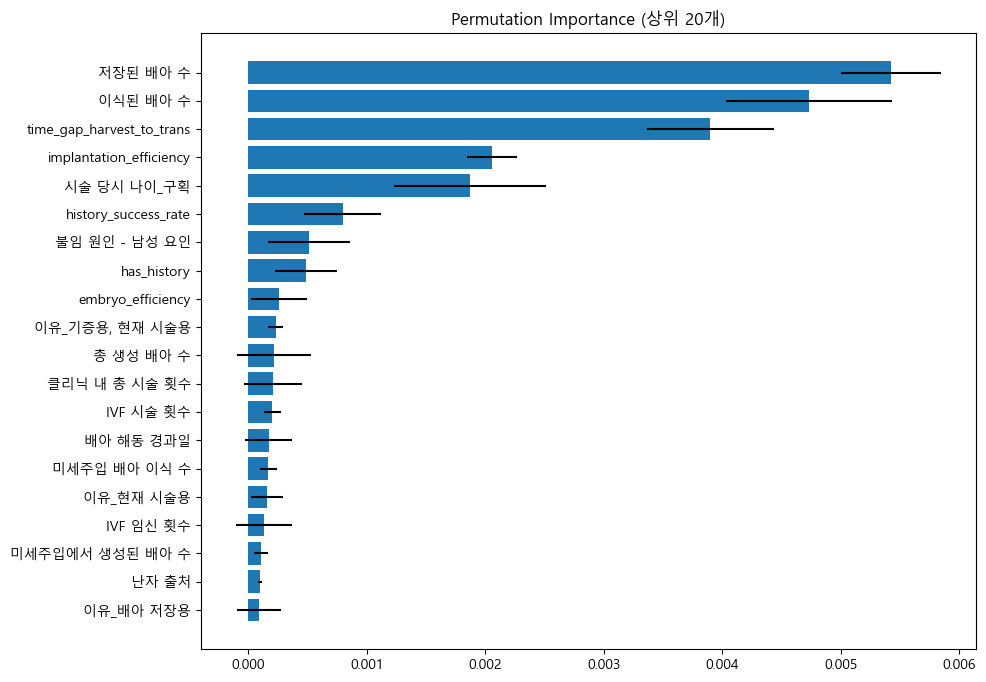

제거해도 무방한 변수: 58개
['has_mixing_process', '이유_연구용, 현재 시술용', '신선 배아 사용 여부_missing', '동결 배아 사용 여부_missing', '불명확 불임 원인', '불임 원인 - 자궁경부 문제', '불임 원인 - 정자 면역학적 요인', '불임 원인 - 정자 농도', '불임 원인 - 정자 형태', '불임 원인 - 정자 운동성', '불임 원인 - 자궁내막증', '시술 유형', '배란 유도 유형', '부부 주 불임 원인', '난자 해동 경과일', 'PGD 시술 여부', '이유_기증용', '정자 기증자 나이_구획', '동결 배아 사용 여부', '불임 원인 - 여성 요인', 'DI 출산 횟수', 'PGS 시술 여부', 'DI 임신 횟수', '난자 기증자 나이_구획', '대리모 여부', '저장된 신선 난자 수', 'is_delayed_trans', 'is_complex_cause', 'transfer_efficiency', 'embryo_yield_rate', '이유_배아 저장용, 현재 시술용', '대리모 여부_missing', '기증 배아 사용 여부_missing', '단일 배아 이식 여부_missing', '이유_난자 저장용', '이유_난자 저장용, 현재 시술용', '이유_난자 저장용, 배아 저장용', '이유_난자 저장용, 배아 저장용, 연구용', '이유_기증용, 배아 저장용', '이유_기증용, 난자 저장용', '이유_기증용, 배아 저장용, 현재 시술용', '남성 주 불임 원인', '해동된 배아 수', '총 시술 횟수', '불임 원인 - 난관 질환', 'IVF 출산 횟수', '기증자 정자와 혼합된 난자 수', '부부 부 불임 원인', 'age_x_cause_count', '여성 주 불임 원인', '불임 원인 - 배란 장애', '단일 배아 이식 여부', 'DI 시술 횟수', 'total_causes_count', 'is_elective_SET', '정자 출처', 'egg_to_age_ratio', '시술 시기 코드']


In [45]:
from sklearn.inspection import permutation_importance

# 1. 먼저 permutation_importance를 계산하여 result를 만듭니다.
# n_repeats=5 정도로 하면 계산이 훨씬 빠릅니다.
result = permutation_importance(best_model, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)

# 2. 이제 result가 준비되었으니, 한글 매핑을 적용하여 데이터프레임 생성
feat_importances = pd.DataFrame({
    # col_mapping을 사용하여 'col_0' -> '한글이름'으로 치환
    'feature': [col_mapping.get(col, col) for col in X_val.columns],
    'importance': result.importances_mean,
    'std': result.importances_std
})

# 3. 중요도 순으로 정렬
feat_importances = feat_importances.sort_values(by='importance', ascending=False)

# 4. 상위 20개 시각화
plt.figure(figsize=(10, 8))
plt.barh(feat_importances['feature'][:20], feat_importances['importance'][:20], xerr=feat_importances['std'][:20])
plt.gca().invert_yaxis()
plt.title("Permutation Importance (상위 20개)")
plt.show()

# 5. 중요도가 0 이하인 변수 리스트 출력
drop_list = feat_importances[feat_importances['importance'] <= 0]['feature'].tolist()
print(f"제거해도 무방한 변수: {len(drop_list)}개")
print(drop_list)

In [37]:
null_info = pd.DataFrame({
    'Missing_Count': train_df.isnull().sum(),
    'Missing_Ratio': train_df.isnull().mean() * 100
})

# 결측치가 있는 컬럼만 내림차순 정렬
null_info = null_info[null_info['Missing_Count'] > 0].sort_values(by='Missing_Ratio', ascending=False)

print(null_info)

Empty DataFrame
Columns: [Missing_Count, Missing_Ratio]
Index: []
